## MolReps

In [59]:
from pathlib import Path
import pandas as pd

tmp_dir = Path("results")
conversion_dir = tmp_dir / "mol_rep_conversion" / "v1.1"
ocr_dir = tmp_dir / "mol_rep_ocr" / "v1.1"
rollout_dir = tmp_dir / "pass_at_k"

In [60]:
from src.utils import compute_mol_metrics

def aggregate_func(df):
    return pd.Series({
        "num_samples": df.shape[0],
        "gt_valid_ratio": df["is_gt_valid"].mean() * 100,
        "pred_valid_ratio": df["is_pred_valid"].mean() * 100,
        "em_ratio": df["is_em"].mean() * 100,
        "can_smiles_match_ratio": df["is_can_smiles_match"].mean() * 100,
        "inchikey_match_ratio": df["is_inchikey_match"].mean() * 100,
        "tanimoto_sim_mean": df["tanimoto_sim"].mean(),
        "tanimoto_sim_median": df["tanimoto_sim"].median(),
        "tanimoto_sim_q1": df["tanimoto_sim"].quantile(0.25),
        "tanimoto_sim_q3": df["tanimoto_sim"].quantile(0.75),
        "tanimoto_sim_p90": df["tanimoto_sim"].quantile(0.9),
        "tanimoto_sim_std": df["tanimoto_sim"].std(),
    })

agg_col_names = {
    "num_samples": "N",
    "gt_valid_ratio": "GT Valid. (\\%)",
    "pred_valid_ratio": "Valid. (\\%)",
    "em_ratio": "EM (\\%)",
    "can_smiles_match_ratio": "CSM (\\%)",
    "inchikey_match_ratio": "IKM (\\%)",
    "tanimoto_sim_mean": "TS ($\\mu$)",
    "tanimoto_sim_median": "TS (Med.)",
    "tanimoto_sim_q1": "TS (Q1)",
    "tanimoto_sim_q3": "TS (Q3)",
    "tanimoto_sim_p90": "TS$_{90}$",
    "tanimoto_sim_std": "TS (SD)"
}

In [98]:
import numpy as np

def bootstrap_aggregate_func(df, groupby_cols, n_bootstrap=1000):
    """
    Bootstrap resampling for grouped data.
    Returns mean ± std format for each metric.
    
    Args:
        df: Input DataFrame
        groupby_cols: List of columns to group by
        n_bootstrap: Number of bootstrap iterations
    
    Returns:
        DataFrame with bootstrap results in 'mean ± std' format
    """
    col_names = {
        "is_pred_valid": "Valid. (\\%)",
        "is_em": "EM (\\%)",
        "is_can_smiles_match": "CSM (\\%)",
        "is_inchikey_match": "IKM (\\%)",
        "tanimoto_sim": "TS",
    }
    
    metric_cols = ["is_pred_valid", "is_em", "is_can_smiles_match", "is_inchikey_match", "tanimoto_sim"]
    
    def compute_bootstrap(group_df):
        n_samples = group_df.shape[0]
        results = {}
        results["N"] = n_samples
        
        for metric in metric_cols:
            bootstrap_values = []
            for _ in range(n_bootstrap):
                boot_sample = group_df.sample(n=n_samples, replace=True)
                bootstrap_values.append(boot_sample[metric].mean())
            
            bootstrap_values = np.array(bootstrap_values)
            mean_val = np.mean(bootstrap_values)
            std_val = np.std(bootstrap_values, ddof=1)
            
            display_name = col_names.get(metric, metric)
            if "\\%" in display_name:
                results[display_name] = f"{mean_val*100:.2f}$_{{\\pm {std_val*100:.2f}}}$"
            else:
                results[display_name] = f"{mean_val:.2f}$_{{\\pm {std_val:.2f}}}$"
        
        return pd.Series(results)
    
    return df.groupby(groupby_cols, observed=True)[metric_cols].apply(compute_bootstrap).reset_index()

In [105]:
def prepare_raw_responses(dir: str|Path) -> pd.DataFrame:
    dir = Path(dir)
    if "raw_responses" not in [f.name for f in dir.iterdir() if f.is_dir()]:
        raise ValueError(f"Directory {dir} does not contain a 'raw_responses' subdirectory.")
    raw_responses = pd.DataFrame()
    for file in (dir / "raw_responses").glob("*.jsonl"):
        df = pd.read_json(file, lines=True)
        raw_responses = pd.concat([raw_responses, df], axis=0, ignore_index=True)

    raw_responses_df = raw_responses.copy()
    raw_responses_df[['is_gt_valid', 'is_pred_valid', 'is_em', 'is_can_smiles_match', 'is_inchikey_match', 'tanimoto_sim', '_parse_status']] = raw_responses_df.apply(lambda row: compute_mol_metrics(row["completion"], row["raw_responses"], row["output_rep_type"]), axis=1, result_type="expand")

    col_names = {
        "model_name": "Model",
        "model_stage": "Model Version",
        "task_type": "Tasks",
        "input_rep_type": "Input Rep. Type",
        "output_rep_type": "Output Rep. Type",
    }

    raw_responses_df = raw_responses_df.rename(columns=col_names)

    def _rename_model_name(df):
        tmp_map = {
            "qwen3_4b_i": "Q3-4B-I",
            "qwen3_4b_i_sft_lora_conversion": "MQ3-4B-I",

            "qwen3_vl_4b_i": "Q3-VL-4B-I",
            "qwen3_vl_4b_i_sft_lora_ocr": "MQ3-VL-4B-I$_{OCR}$",
            "qwen3_vl_4b_i_sft_lora_conversion": "MQ3-VL-4B-I$_{Conv.}$",
            "qwen3_vl_4b_i_sft_lora_ocr_conversion": "MQ3-VL-4B-I",
            
            "qwen3_vl_4b_i_grpo_lora_from_sft_lora_ocr_conversion": "MQ3-VL-4B-I$_{GRPO}$",
        }
        df["Model"] = df["Model"].replace(tmp_map)
        model_name_order = [
            "Q3-4B-I",
            "MQ3-4B-I",
            
            "Q3-VL-4B-I",
            "MQ3-VL-4B-I$_{OCR}$",
            "MQ3-VL-4B-I$_{Conv.}$",
            "MQ3-VL-4B-I",
            "MQ3-VL-4B-I$_{GRPO}$",
        ]
        df["Model"] = pd.Categorical(df["Model"], categories=model_name_order, ordered=True)
        return df

    def _rename_task_type(df):
        task_names = {
            "can_reps_translation": "Rep. Trans.",
            "iupac_understanding": "IUPAC Und.",
            "cml_understanding": "CML Und.",
            "intra_rep_normalization": "Intra Norm.",
            "cross_rep_normalization": "Cross Norm.",
            "ocr": "OCR",
        }
        df["Tasks"] = df["Tasks"].replace(task_names)
        task_type_order = [
            "Rep. Trans.",
            "IUPAC Und.",
            "CML Und.",
            "Intra Norm.",
            "Cross Norm.",
            "OCR"
        ]
        df["Tasks"] = pd.Categorical(df["Tasks"], categories=task_type_order, ordered=True)
        return df

    def _rename_output_rep_type(df):
        output_rep_type_names = {
            "can_smiles": "SMILES",
            "can_selfies": "SELFIES",
            "can_deepsmiles": "DeepSMILES",
            "inchi": "InChI",
        }
        df["Output Rep. Type"] = df["Output Rep. Type"].replace(output_rep_type_names)
        output_rep_type_order = [
            "SMILES",
            "SELFIES",
            "DeepSMILES",
            "InChI"
        ]
        df["Output Rep. Type"] = pd.Categorical(df["Output Rep. Type"], categories=output_rep_type_order, ordered=True)
        return df

    def _rename_model_version(df):
        model_version_names = {
            "base": "Base",
            "sft": "Trained"
        }
        df["Model Version"] = df["Model Version"].replace(model_version_names)
        model_version_order = [
            "Base",
            "Trained",
        ]
        df["Model Version"] = pd.Categorical(df["Model Version"], categories=model_version_order, ordered=True)
        return df
    
    def _rename_input_rep_type(df):
        input_rep_type_names = {
            "can_smiles": "SMILES",
            "can_selfies": "SELFIES",
            "can_deepsmiles": "DeepSMILES",
            "random_smiles": "R. SMILES",
            "random_selfies": "R. SELFIES",
            "random_deepsmiles": "R. DeepSMILES",
            "inchi": "InChI",
            "iupac": "IUPAC",
            "cml": "CML",
            "mol_image": "Mol. Image",
        }
        df["Input Rep. Type"] = df["Input Rep. Type"].replace(input_rep_type_names)
        input_rep_type_order = [
            "SMILES",
            "SELFIES",
            "DeepSMILES",
            "InChI",
            "R. SMILES",
            "R. SELFIES",
            "R. DeepSMILES",
            "IUPAC",
            "CML",
            "Mol. Image"
        ]
        df["Input Rep. Type"] = pd.Categorical(df["Input Rep. Type"], categories=input_rep_type_order, ordered=True)
        return df

    raw_responses_df = _rename_model_name(raw_responses_df)
    raw_responses_df = _rename_task_type(raw_responses_df)
    raw_responses_df = _rename_output_rep_type(raw_responses_df)
    raw_responses_df = _rename_model_version(raw_responses_df)
    raw_responses_df = _rename_input_rep_type(raw_responses_df)

    return raw_responses_df

def latex_rotate_trans(index: str):
    return f"\\rotatebox{{90}}{{{index}}}"


In [106]:
conversion_df = prepare_raw_responses(conversion_dir)
extra_conv_df = prepare_raw_responses(conversion_dir / "extra_test")
ocr_df = prepare_raw_responses(ocr_dir)
extra_ocr_df = prepare_raw_responses(ocr_dir / "extra_test")

### Table2: Base v.s. MolQwen3 (split by conv. tasks)

In [99]:
groupby_cols = ["Model Version", "Model", "Tasks"]
tmp_df = bootstrap_aggregate_func(conversion_df, groupby_cols)

tmp_df

,Model Version,Model,Tasks,N,Valid. (\%),EM (\%),CSM (\%),IKM (\%),TS
0,Base,Q3-4B-I,Rep. Trans.,247,15.11$_{\pm 2.26}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.01$_{\pm 0.00}$
1,Base,Q3-4B-I,IUPAC Und.,69,27.34$_{\pm 5.23}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.02$_{\pm 0.01}$
2,Base,Q3-4B-I,CML Und.,76,11.86$_{\pm 3.66}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$
3,Base,Q3-4B-I,Intra Norm.,114,49.12$_{\pm 4.71}$,0.00$_{\pm 0.00}$,30.66$_{\pm 4.35}$,30.79$_{\pm 4.46}$,0.39$_{\pm 0.04}$
4,Base,Q3-4B-I,Cross Norm.,369,15.21$_{\pm 1.84}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.01$_{\pm 0.00}$
5,Base,Q3-VL-4B-I,Rep. Trans.,247,5.59$_{\pm 1.46}$,0.36$_{\pm 0.39}$,0.41$_{\pm 0.40}$,0.40$_{\pm 0.40}$,0.01$_{\pm 0.00}$
6,Base,Q3-VL-4B-I,IUPAC Und.,69,13.06$_{\pm 3.99}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.02$_{\pm 0.01}$
7,Base,Q3-VL-4B-I,CML Und.,76,16.69$_{\pm 4.22}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.01$_{\pm 0.00}$
8,Base,Q3-VL-4B-I,Intra Norm.,114,70.08$_{\pm 4.36}$,0.00$_{\pm 0.00}$,53.32$_{\pm 4.45}$,53.56$_{\pm 4.85}$,0.61$_{\pm 0.04}$
9,Base,Q3-VL-4B-I,Cross Norm.,369,8.68$_{\pm 1.39}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.01$_{\pm 0.00}$


In [100]:
clean_df = tmp_df.copy()
clean_df = clean_df.drop(columns=["N", "EM (\\%)", "CSM (\\%)"])
clean_df = clean_df[~clean_df.Model.isin(["MQ3-VL-4B-I$_{OCR}$", "MQ3-VL-4B-I$_{Conv.}$"])]

clean_df["Model Version"] = clean_df["Model Version"].apply(latex_rotate_trans)
# clean_df["Model"] = clean_df["Model"].apply(latex_rotate_trans)

clean_df = clean_df.set_index(["Model Version", "Model", "Tasks"])

clean_df

Valid. (\%)  \
Model Version           Model       Tasks                             
\rotatebox{90}{Base}    Q3-4B-I     Rep. Trans.  15.11$_{\pm 2.26}$   
                                    IUPAC Und.   27.34$_{\pm 5.23}$   
                                    CML Und.     11.86$_{\pm 3.66}$   
                                    Intra Norm.  49.12$_{\pm 4.71}$   
                                    Cross Norm.  15.21$_{\pm 1.84}$   
                        Q3-VL-4B-I  Rep. Trans.   5.59$_{\pm 1.46}$   
                                    IUPAC Und.   13.06$_{\pm 3.99}$   
                                    CML Und.     16.69$_{\pm 4.22}$   
                                    Intra Norm.  70.08$_{\pm 4.36}$   
                                    Cross Norm.   8.68$_{\pm 1.39}$   
\rotatebox{90}{Trained} MQ3-4B-I    Rep. Trans.  88.61$_{\pm 2.00}$   
                                    IUPAC Und.   74.04$_{\pm 5.42}$   
                                    CML Und.     77.18$_{\pm 4.95}$   
                                    Intra Norm.  98.27$_{\pm 1.25}$   
                                    Cross Norm.  95.60$_{\pm 1.06}$   
                        MQ3-VL-4B-I Rep. Trans.  91.21$_{\pm 1.78}$   
                                    IUPAC Und.   76.64$_{\pm 5.13}$   
                                    CML Und.     85.40$_{\pm 4.06}$   
                                    Intra Norm.  98.30$_{\pm 1.18}$   
                                    Cross Norm.  92.93$_{\pm 1.34}$   

                                                           IKM (\%)  \
Model Version           Model       Tasks                             
\rotatebox{90}{Base}    Q3-4B-I     Rep. Trans.   0.00$_{\pm 0.00}$   
                                    IUPAC Und.    0.00$_{\pm 0.00}$   
                                    CML Und.      0.00$_{\pm 0.00}$   
                                    Intra Norm.  30.79$_{\pm 4.46}$   
                                    Cross Norm.   0.00$_{\pm 0.00}$   
                        Q3-VL-4B-I  Rep. Trans.   0.40$_{\pm 0.40}$   
                                    IUPAC Und.    0.00$_{\pm 0.00}$   
                                    CML Und.      0.00$_{\pm 0.00}$   
                                    Intra Norm.  53.56$_{\pm 4.85}$   
                                    Cross Norm.   0.00$_{\pm 0.00}$   
\rotatebox{90}{Trained} MQ3-4B-I    Rep. Trans.  68.23$_{\pm 3.00}$   
                                    IUPAC Und.   37.60$_{\pm 5.79}$   
                                    CML Und.     56.89$_{\pm 5.70}$   
                                    Intra Norm.  80.78$_{\pm 3.65}$   
                                    Cross Norm.  88.61$_{\pm 1.69}$   
                        MQ3-VL-4B-I Rep. Trans.  67.54$_{\pm 2.96}$   
                                    IUPAC Und.   36.14$_{\pm 5.89}$   
                                    CML Und.     56.74$_{\pm 5.75}$   
                                    Intra Norm.  77.15$_{\pm 4.01}$   
                                    Cross Norm.  85.99$_{\pm 1.83}$   

                                                                TS  
Model Version           Model       Tasks                           
\rotatebox{90}{Base}    Q3-4B-I     Rep. Trans.  0.01$_{\pm 0.00}$  
                                    IUPAC Und.   0.02$_{\pm 0.01}$  
                                    CML Und.     0.00$_{\pm 0.00}$  
                                    Intra Norm.  0.39$_{\pm 0.04}$  
                                    Cross Norm.  0.01$_{\pm 0.00}$  
                        Q3-VL-4B-I  Rep. Trans.  0.01$_{\pm 0.00}$  
                                    IUPAC Und.   0.02$_{\pm 0.01}$  
                                    CML Und.     0.01$_{\pm 0.00}$  
                                    Intra Norm.  0.61$_{\pm 0.04}$  
                                    Cross Norm.  0.01$_{\pm 0.00}$  
\rotatebox{90}{Trained} MQ3-4B-I    Rep. Trans.  0.76$_{\pm 0.03}$  
                                 

In [101]:
print(clean_df.to_latex(
    index=True,
))

\begin{tabular}{llllll}
\toprule
 &  &  & Valid. (\%) & IKM (\%) & TS \\
Model Version & Model & Tasks &  &  &  \\
\midrule
\multirow[t]{10}{*}{\rotatebox{90}{Base}} & \multirow[t]{5}{*}{Q3-4B-I} & Rep. Trans. & 15.11$_{\pm 2.26}$ & 0.00$_{\pm 0.00}$ & 0.01$_{\pm 0.00}$ \\
 &  & IUPAC Und. & 27.34$_{\pm 5.23}$ & 0.00$_{\pm 0.00}$ & 0.02$_{\pm 0.01}$ \\
 &  & CML Und. & 11.86$_{\pm 3.66}$ & 0.00$_{\pm 0.00}$ & 0.00$_{\pm 0.00}$ \\
 &  & Intra Norm. & 49.12$_{\pm 4.71}$ & 30.79$_{\pm 4.46}$ & 0.39$_{\pm 0.04}$ \\
 &  & Cross Norm. & 15.21$_{\pm 1.84}$ & 0.00$_{\pm 0.00}$ & 0.01$_{\pm 0.00}$ \\
\cline{2-6}
 & \multirow[t]{5}{*}{Q3-VL-4B-I} & Rep. Trans. & 5.59$_{\pm 1.46}$ & 0.40$_{\pm 0.40}$ & 0.01$_{\pm 0.00}$ \\
 &  & IUPAC Und. & 13.06$_{\pm 3.99}$ & 0.00$_{\pm 0.00}$ & 0.02$_{\pm 0.01}$ \\
 &  & CML Und. & 16.69$_{\pm 4.22}$ & 0.00$_{\pm 0.00}$ & 0.01$_{\pm 0.00}$ \\
 &  & Intra Norm. & 70.08$_{\pm 4.36}$ & 53.56$_{\pm 4.85}$ & 0.61$_{\pm 0.04}$ \\
 &  & Cross Norm. & 8.68$_{\pm 1.39

### Table3: Base model v.s. Trained Model: Input Rep v.s. Output Rep

In [104]:
tmp_df.Model.value_counts()

Model
Q3-4B-I                  32
Q3-VL-4B-I               32
MQ3-4B-I                 32
MQ3-VL-4B-I$_{OCR}$      32
MQ3-VL-4B-I$_{Conv.}$    32
MQ3-VL-4B-I              32
MQ3-VL-4B-I$_{GRPO}$      0
Name: count, dtype: int64

In [107]:
groupby_cols = ["Model Version", "Input Rep. Type", "Output Rep. Type"]
tmp_df = conversion_df[conversion_df.Model.isin(["Q3-4B-I", "Q3-VL-4B-I", "MQ3-4B-I", "MQ3-VL-4B-I"])]
tmp_df = bootstrap_aggregate_func(tmp_df, groupby_cols)
tmp_df

,Model Version,Input Rep. Type,Output Rep. Type,N,Valid. (\%),EM (\%),CSM (\%),IKM (\%),TS
0,Base,SMILES,SELFIES,36,25.27$_{\pm 7.12}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$
1,Base,SMILES,DeepSMILES,34,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$
2,Base,SMILES,InChI,38,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$
3,Base,SELFIES,SMILES,32,18.57$_{\pm 6.63}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.02$_{\pm 0.01}$
4,Base,SELFIES,DeepSMILES,50,4.07$_{\pm 2.72}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$,0.00$_{\pm 0.00}$
...,...,...,...,...,...,...,...,...,...
59,Trained,IUPAC,InChI,40,47.57$_{\pm 8.08}$,32.41$_{\pm 7.22}$,32.53$_{\pm 7.37}$,32.45$_{\pm 7.34}$,0.42$_{\pm 0.07}$
60,Trained,CML,SMILES,34,88.35$_{\pm 5.40}$,55.94$_{\pm 8.70}$,55.98$_{\pm 8.59}$,55.84$_{\pm 8.35}$,0.72$_{\pm 0.07}$
61,Trained,CML,SELFIES,34,100.00$_{\pm 0.00}$,53.04$_{\pm 8.22}$,52.45$_{\pm 8.96}$,53.04$_{\pm 8.45}$,0.72$_{\pm 0.07}$
62,Trained,CML,DeepSMILES,48,81.54$_{\pm 5.70}$,66.89$_{\pm 6.88}$,66.99$_{\pm 6.60}$,66.63$_{\pm 6.87}$,0.75$_{\pm 0.06}$


In [123]:
clean_df = tmp_df.copy()
clean_df = clean_df.drop(columns=["N", "Valid. (\\%)", "EM (\\%)", "CSM (\\%)", "TS"])

clean_df["Model Version"] = clean_df["Model Version"].apply(latex_rotate_trans)
# clean_df = clean_df.pivot_table(index=["Model Version", "Input Rep. Type"], columns=["Output Rep. Type"], values="IKM (\\%)")
clean_df = clean_df.set_index(["Model Version", "Input Rep. Type", "Output Rep. Type"]).unstack(-1)

clean_df

IKM (\%)  \
Output Rep. Type                                     SMILES   
Model Version           Input Rep. Type                       
\rotatebox{90}{Base}    SMILES                          NaN   
                        SELFIES           0.00$_{\pm 0.00}$   
                        DeepSMILES        2.22$_{\pm 2.21}$   
                        InChI             0.00$_{\pm 0.00}$   
                        R. SMILES        30.68$_{\pm 5.54}$   
                        R. SELFIES        0.00$_{\pm 0.00}$   
                        R. DeepSMILES     0.00$_{\pm 0.00}$   
                        IUPAC             0.00$_{\pm 0.00}$   
                        CML               0.00$_{\pm 0.00}$   
\rotatebox{90}{Trained} SMILES                          NaN   
                        SELFIES          83.86$_{\pm 6.31}$   
                        DeepSMILES       86.16$_{\pm 5.09}$   
                        InChI            19.06$_{\pm 6.17}$   
                        R. SMILES        95.60$_{\pm 2.51}$   
                        R. SELFIES       83.41$_{\pm 3.75}$   
                        R. DeepSMILES    94.26$_{\pm 2.52}$   
                        IUPAC            46.00$_{\pm 9.73}$   
                        CML              55.84$_{\pm 8.35}$   

                                                             \
Output Rep. Type                                    SELFIES   
Model Version           Input Rep. Type                       
\rotatebox{90}{Base}    SMILES            0.00$_{\pm 0.00}$   
                        SELFIES                         NaN   
                        DeepSMILES        0.00$_{\pm 0.00}$   
                        InChI             0.00$_{\pm 0.00}$   
                        R. SMILES         0.00$_{\pm 0.00}$   
                        R. SELFIES       73.90$_{\pm 4.69}$   
                        R. DeepSMILES     0.00$_{\pm 0.00}$   
                        IUPAC             0.00$_{\pm 0.00}$   
                        CML               0.00$_{\pm 0.00}$   
\rotatebox{90}{Trained} SMILES           85.94$_{\pm 5.79}$   
                        SELFIES                         NaN   
                        DeepSMILES       81.62$_{\pm 5.91}$   
                        InChI             7.19$_{\pm 3.91}$   
                        R. SMILES        80.82$_{\pm 4.68}$   
                        R. SELFIES       60.07$_{\pm 4.98}$   
                        R. DeepSMILES    79.87$_{\pm 4.80}$   
                        IUPAC            27.09$_{\pm 6.58}$   
                        CML              53.04$_{\pm 8.45}$   

                                                             \
Output Rep. Type                                 DeepSMILES   
Model Version           Input Rep. Type                       
\rotatebox{90}{Base}    SMILES            0.00$_{\pm 0.00}$   
                        SELFIES           0.00$_{\pm 0.00}$   
                        DeepSMILES                      NaN   
                        InChI             0.00$_{\pm 0.00}$   
                        R. SMILES         0.00$_{\pm 0.00}$   
                        R. SELFIES        0.00$_{\pm 0.00}$   
                        R. DeepSMILES    13.77$_{\pm 4.18}$   
                        IUPAC             0.00$_{\pm 0.00}$   
                        CML               0.00$_{\pm 0.00}$   
\rotatebox{90}{Trained} SMILES           79.53$_{\pm 6.92}$   
                        SELFIES          90.12$_{\pm 4.32}$   
                        DeepSMILES                      NaN   
                        InChI            16.69$_{\pm 5.50}$   
                        R. SMILES        88.73$_{\pm 3.34}$   
                        R. SELFIES       85.65$_{\pm 4.41}$   
                        R. DeepSMILES    86.27$_{\pm 3.97}$   
                        IUPAC            50.30$_{\pm 9.64}$   
                        CML              66.63$_{\pm 6.87}$   

                                                              
Output Rep. Type

In [124]:
print(clean_df.to_latex(
    # float_format="%.2f",
    index=True,
    na_rep="--",
))

\begin{tabular}{llllll}
\toprule
 &  & \multicolumn{4}{r}{IKM (\%)} \\
 & Output Rep. Type & SMILES & SELFIES & DeepSMILES & InChI \\
Model Version & Input Rep. Type &  &  &  &  \\
\midrule
\multirow[t]{9}{*}{\rotatebox{90}{Base}} & SMILES & -- & 0.00$_{\pm 0.00}$ & 0.00$_{\pm 0.00}$ & 0.00$_{\pm 0.00}$ \\
 & SELFIES & 0.00$_{\pm 0.00}$ & -- & 0.00$_{\pm 0.00}$ & 0.00$_{\pm 0.00}$ \\
 & DeepSMILES & 2.22$_{\pm 2.21}$ & 0.00$_{\pm 0.00}$ & -- & 0.00$_{\pm 0.00}$ \\
 & InChI & 0.00$_{\pm 0.00}$ & 0.00$_{\pm 0.00}$ & 0.00$_{\pm 0.00}$ & -- \\
 & R. SMILES & 30.68$_{\pm 5.54}$ & 0.00$_{\pm 0.00}$ & 0.00$_{\pm 0.00}$ & 0.00$_{\pm 0.00}$ \\
 & R. SELFIES & 0.00$_{\pm 0.00}$ & 73.90$_{\pm 4.69}$ & 0.00$_{\pm 0.00}$ & 0.00$_{\pm 0.00}$ \\
 & R. DeepSMILES & 0.00$_{\pm 0.00}$ & 0.00$_{\pm 0.00}$ & 13.77$_{\pm 4.18}$ & 0.00$_{\pm 0.00}$ \\
 & IUPAC & 0.00$_{\pm 0.00}$ & 0.00$_{\pm 0.00}$ & 0.00$_{\pm 0.00}$ & 0.00$_{\pm 0.00}$ \\
 & CML & 0.00$_{\pm 0.00}$ & 0.00$_{\pm 0.00}$ & 0.00$_{\pm 0.00}$

### Table4: LLM v.s. VLM

In [125]:
combined_df = pd.concat([conversion_df, ocr_df], ignore_index=True)
combined_df["Test Subset"] = "ID"

extra_combined_df = pd.concat([extra_conv_df, extra_ocr_df], ignore_index=True)
extra_combined_df["Test Subset"] = "OOD"

big_combined_df = pd.concat([combined_df, extra_combined_df], ignore_index=True)

In [126]:
test_subset_order = ["ID", "OOD"]
big_combined_df["Test Subset"] = pd.Categorical(big_combined_df["Test Subset"], categories=test_subset_order, ordered=True)

tmp_col_names = {
    "model_modality": "Model Type",
    "task_name": "Task Type",
}
model_modality_map = {
    "llm": "LLM",
    "vlm": "MLLM",
}
model_modality_order = ["LLM", "MLLM"]
task_name_map = {
    "mol_rep_conversion": "Conv.",
    "mol_rep_ocr": "OCR",
}
task_name_order = ["Conv.", "OCR"]

big_combined_df = big_combined_df.rename(columns=tmp_col_names)

big_combined_df["Model Type"] = big_combined_df["Model Type"].replace(model_modality_map)
big_combined_df["Model Type"] = pd.Categorical(big_combined_df["Model Type"], categories=model_modality_order, ordered=True)
big_combined_df["Task Type"] = big_combined_df["Task Type"].replace(task_name_map)
big_combined_df["Task Type"] = pd.Categorical(big_combined_df["Task Type"], categories=task_name_order, ordered=True)

In [127]:
# tmp_df = big_combined_df.groupby(["Test Subset", "Task Type", "Model Type", "Model"], observed=True)[big_combined_df.columns].apply(aggregate_func).reset_index()
# tmp_df = tmp_df.rename(columns=agg_col_names)

groupby = ["Test Subset", "Task Type", "Model Type", "Model"]
tmp_df = bootstrap_aggregate_func(big_combined_df, groupby)
tmp_df

,Test Subset,Task Type,Model Type,Model,N,Valid. (\%),EM (\%),CSM (\%),IKM (\%),TS
0,ID,Conv.,LLM,Q3-4B-I,875,20.15$_{\pm 1.31}$,0.00$_{\pm 0.00}$,4.02$_{\pm 0.69}$,4.01$_{\pm 0.67}$,0.06$_{\pm 0.01}$
1,ID,Conv.,LLM,MQ3-4B-I,875,90.69$_{\pm 1.00}$,75.11$_{\pm 1.39}$,74.96$_{\pm 1.41}$,75.13$_{\pm 1.50}$,0.81$_{\pm 0.01}$
2,ID,Conv.,MLLM,Q3-VL-4B-I,875,16.91$_{\pm 1.30}$,0.12$_{\pm 0.12}$,7.08$_{\pm 0.89}$,7.11$_{\pm 0.84}$,0.09$_{\pm 0.01}$
3,ID,Conv.,MLLM,MQ3-VL-4B-I$_{OCR}$,875,25.50$_{\pm 1.51}$,0.00$_{\pm 0.00}$,5.06$_{\pm 0.72}$,5.01$_{\pm 0.78}$,0.09$_{\pm 0.01}$
4,ID,Conv.,MLLM,MQ3-VL-4B-I$_{Conv.}$,875,89.39$_{\pm 1.04}$,70.86$_{\pm 1.58}$,70.91$_{\pm 1.48}$,70.84$_{\pm 1.55}$,0.78$_{\pm 0.01}$
5,ID,Conv.,MLLM,MQ3-VL-4B-I,875,91.22$_{\pm 0.95}$,73.09$_{\pm 1.51}$,73.26$_{\pm 1.50}$,73.14$_{\pm 1.51}$,0.80$_{\pm 0.01}$
6,ID,OCR,MLLM,Q3-VL-4B-I,80,23.51$_{\pm 4.78}$,0.00$_{\pm 0.00}$,1.25$_{\pm 1.20}$,1.28$_{\pm 1.21}$,0.08$_{\pm 0.02}$
7,ID,OCR,MLLM,MQ3-VL-4B-I$_{OCR}$,80,43.61$_{\pm 5.46}$,3.81$_{\pm 2.23}$,3.75$_{\pm 2.17}$,3.91$_{\pm 2.08}$,0.18$_{\pm 0.03}$
8,ID,OCR,MLLM,MQ3-VL-4B-I$_{Conv.}$,80,63.57$_{\pm 5.20}$,20.19$_{\pm 4.57}$,20.11$_{\pm 4.51}$,19.94$_{\pm 4.52}$,0.34$_{\pm 0.04}$
9,ID,OCR,MLLM,MQ3-VL-4B-I,80,68.55$_{\pm 5.09}$,26.14$_{\pm 4.98}$,26.42$_{\pm 4.97}$,26.06$_{\pm 4.96}$,0.41$_{\pm 0.05}$


In [135]:
clean_df = tmp_df.copy()
# clean_df = clean_df[clean_df["Task Type"] == "Conv."]
clean_df = clean_df.drop(columns=["N", "EM (\\%)", "CSM (\\%)"])
# clean_df = clean_df.pivot_table(index=["Model Version", "Input Rep. Type"], columns=["Output Rep. Type"], values=["Valid.", "IKM", "TS"])
# clean_df.columns = clean_df.columns.swaplevel(0, 1)
# clean_df = clean_df.sort_index(axis=1, level=0)

# clean_df["Test Subset"] = clean_df["Test Subset"].apply(lambda x: f"\\rotatebox{{90}}{{{x}}}")
# clean_df["Model Type"] = clean_df["Model Type"].apply(lambda x: f"\\rotatebox{{90}}{{{x}}}")
clean_df["Task Type"] = clean_df["Task Type"].apply(lambda x: f"\\rotatebox{{90}}{{{x}}}")

clean_df = clean_df.set_index(["Task Type", "Test Subset", "Model Type", "Model"])
clean_df = clean_df.sort_index()

# clean_df = clean_df.unstack(level="Test Subset")
# clean_df = clean_df.swaplevel(0, 1, axis=1)
# clean_df = clean_df.sort_index(axis=1, level=0)

# desired_order = ["Valid. (\\%)", "IKM (\\%)", "TS"]
# new_columns = []
# for subset in clean_df.columns.get_level_values(0).unique():
#     for metric in desired_order:
#         if (subset, metric) in clean_df.columns:
#             new_columns.append((subset, metric))

# clean_df = clean_df[new_columns]

clean_df

Valid. (\%)  \
Task Type             Test Subset Model Type Model                                       
\rotatebox{90}{Conv.} ID          LLM        Q3-4B-I                20.15$_{\pm 1.31}$   
                                             MQ3-4B-I               90.69$_{\pm 1.00}$   
                                  MLLM       Q3-VL-4B-I             16.91$_{\pm 1.30}$   
                                             MQ3-VL-4B-I$_{OCR}$    25.50$_{\pm 1.51}$   
                                             MQ3-VL-4B-I$_{Conv.}$  89.39$_{\pm 1.04}$   
                                             MQ3-VL-4B-I            91.22$_{\pm 0.95}$   
                      OOD         LLM        Q3-4B-I                20.35$_{\pm 1.36}$   
                                             MQ3-4B-I               58.12$_{\pm 1.71}$   
                                  MLLM       Q3-VL-4B-I             17.19$_{\pm 1.29}$   
                                             MQ3-VL-4B-I$_{OCR}$    29.78$_{\pm 1.56}$   
                                             MQ3-VL-4B-I$_{Conv.}$  62.44$_{\pm 1.62}$   
                                             MQ3-VL-4B-I            59.34$_{\pm 1.69}$   
\rotatebox{90}{OCR}   ID          MLLM       Q3-VL-4B-I             23.51$_{\pm 4.78}$   
                                             MQ3-VL-4B-I$_{OCR}$    43.61$_{\pm 5.46}$   
                                             MQ3-VL-4B-I$_{Conv.}$  63.57$_{\pm 5.20}$   
                                             MQ3-VL-4B-I            68.55$_{\pm 5.09}$   
                      OOD         MLLM       Q3-VL-4B-I             18.89$_{\pm 4.39}$   
                                             MQ3-VL-4B-I$_{OCR}$    41.24$_{\pm 5.50}$   
                                             MQ3-VL-4B-I$_{Conv.}$  58.87$_{\pm 5.41}$   
                                             MQ3-VL-4B-I            55.05$_{\pm 5.47}$   

                                                                              IKM (\%)  \
Task Type             Test Subset Model Type Model                                       
\rotatebox{90}{Conv.} ID          LLM        Q3-4B-I                 4.01$_{\pm 0.67}$   
                                             MQ3-4B-I               75.13$_{\pm 1.50}$   
                                  MLLM       Q3-VL-4B-I              7.11$_{\pm 0.84}$   
                                             MQ3-VL-4B-I$_{OCR}$     5.01$_{\pm 0.78}$   
                                             MQ3-VL-4B-I$_{Conv.}$  70.84$_{\pm 1.55}$   
                                             MQ3-VL-4B-I            73.14$_{\pm 1.51}$   
                      OOD         LLM        Q3-4B-I                 3.86$_{\pm 0.65}$   
                                             MQ3-4B-I                3.09$_{\pm 0.59}$   
                                  MLLM       Q3-VL-4B-I              6.44$_{\pm 0.82}$   
                                             MQ3-VL-4B-I$_{OCR}$     4.79$_{\pm 0.70}$   
                                             MQ3-VL-4B-I$_{Conv.}$   2.17$_{\pm 0.49}$   
                                             MQ3-VL-4B-I             2.29$_{\pm 0.52}$   
\rotatebox{90}{OCR}   ID          MLLM       Q3-VL-4B-I              1.28$_{\pm 1.21}$   
                                             MQ3-VL-4B-I$_{OCR}$     3.91$_{\pm 2.08}$   
                                             MQ3-VL-4B-I$_{Conv.}$  19.94$_{\pm 4.52}$   
                                             MQ3-VL-4B-I            26.06$_{\pm 4.96}$   
                      OOD         MLLM       Q3-VL-4B-I              1.28$_{\pm 1.21}$   
                                             MQ3-VL-4B-I$_{OCR}$     3.74$_{\pm 2.17}$   
                                             MQ3-VL-4B-I$_{Conv.}$   0.00$_{\pm 0.00}$   
                                             MQ3-VL-4B-I             1.28$_{\pm 1.20}$   

                                                                                   TS  
Task Type             Tes

In [134]:
print(clean_df.to_latex(
    # float_format="%.2f",
    index=True,
))

\begin{tabular}{lllllllll}
\toprule
 &  & Test Subset & \multicolumn{3}{r}{ID} & \multicolumn{3}{r}{OOD} \\
 &  &  & Valid. (\%) & IKM (\%) & TS & Valid. (\%) & IKM (\%) & TS \\
Task Type & Model Type & Model &  &  &  &  &  &  \\
\midrule
\multirow[t]{6}{*}{\rotatebox{90}{Conv.}} & \multirow[t]{2}{*}{LLM} & Q3-4B-I & 20.15$_{\pm 1.31}$ & 4.01$_{\pm 0.67}$ & 0.06$_{\pm 0.01}$ & 20.35$_{\pm 1.36}$ & 3.86$_{\pm 0.65}$ & 0.06$_{\pm 0.01}$ \\
 &  & MQ3-4B-I & 90.69$_{\pm 1.00}$ & 75.13$_{\pm 1.50}$ & 0.81$_{\pm 0.01}$ & 58.12$_{\pm 1.71}$ & 3.09$_{\pm 0.59}$ & 0.22$_{\pm 0.01}$ \\
\cline{2-9}
 & \multirow[t]{4}{*}{MLLM} & Q3-VL-4B-I & 16.91$_{\pm 1.30}$ & 7.11$_{\pm 0.84}$ & 0.09$_{\pm 0.01}$ & 17.19$_{\pm 1.29}$ & 6.44$_{\pm 0.82}$ & 0.09$_{\pm 0.01}$ \\
 &  & MQ3-VL-4B-I$_{OCR}$ & 25.50$_{\pm 1.51}$ & 5.01$_{\pm 0.78}$ & 0.09$_{\pm 0.01}$ & 29.78$_{\pm 1.56}$ & 4.79$_{\pm 0.70}$ & 0.10$_{\pm 0.01}$ \\
 &  & MQ3-VL-4B-I$_{Conv.}$ & 89.39$_{\pm 1.04}$ & 70.84$_{\pm 1.55}$ & 0.78$_{\pm 0.01}

## Ablation on Epoch

In [26]:
from src.utils import compute_mol_metrics

def aggregate_func(df):
    return pd.Series({
        "num_samples": df.shape[0],
        "gt_valid_ratio": df["is_gt_valid"].mean() * 100,
        "pred_valid_ratio": df["is_pred_valid"].mean() * 100,
        "em_ratio": df["is_em"].mean() * 100,
        "can_smiles_match_ratio": df["is_can_smiles_match"].mean() * 100,
        "inchikey_match_ratio": df["is_inchikey_match"].mean() * 100,
        "tanimoto_sim_mean": df["tanimoto_sim"].mean(),
        "tanimoto_sim_median": df["tanimoto_sim"].median(),
        "tanimoto_sim_q1": df["tanimoto_sim"].quantile(0.25),
        "tanimoto_sim_q3": df["tanimoto_sim"].quantile(0.75),
        "tanimoto_sim_p90": df["tanimoto_sim"].quantile(0.9),
        "tanimoto_sim_std": df["tanimoto_sim"].std(),
    })

agg_col_names = {
    "num_samples": "N",
    "gt_valid_ratio": "GT Valid. (\\%)",
    "pred_valid_ratio": "Valid. (\\%)",
    "em_ratio": "EM (\\%)",
    "can_smiles_match_ratio": "CSM (\\%)",
    "inchikey_match_ratio": "IKM (\\%)",
    "tanimoto_sim_mean": "TS ($\\mu$)",
    "tanimoto_sim_median": "TS (Med.)",
    "tanimoto_sim_q1": "TS (Q1)",
    "tanimoto_sim_q3": "TS (Q3)",
    "tanimoto_sim_p90": "TS$_{90}$",
    "tanimoto_sim_std": "TS (SD)"
}

In [27]:
ablation_conv_dir = conversion_dir / "ablation_num_train_epoch"
ablation_ocr_dir = ocr_dir / "ablation_num_train_epoch"

In [28]:
ab_conv_df = prepare_raw_responses(ablation_conv_dir)
ab_ocr_df = prepare_raw_responses(ablation_ocr_dir)

### Figure4: ablation on epochs  

In [29]:
tmp_df = ab_conv_df.copy()
tmp_df = tmp_df.groupby(["Model", "num_train_epoch"], observed=True).apply(aggregate_func).reset_index()
tmp_df = tmp_df.rename(columns=agg_col_names)

# tmp_df

/var/folders/rl/5b3t40ps0g7fsjfh2c937v0c0000gn/T/ipykernel_1303/1454298914.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp_df = tmp_df.groupby(["Model", "num_train_epoch"], observed=True).apply(aggregate_func).reset_index()


<Axes: xlabel='num_train_epoch', ylabel='IKM (\\%)'>

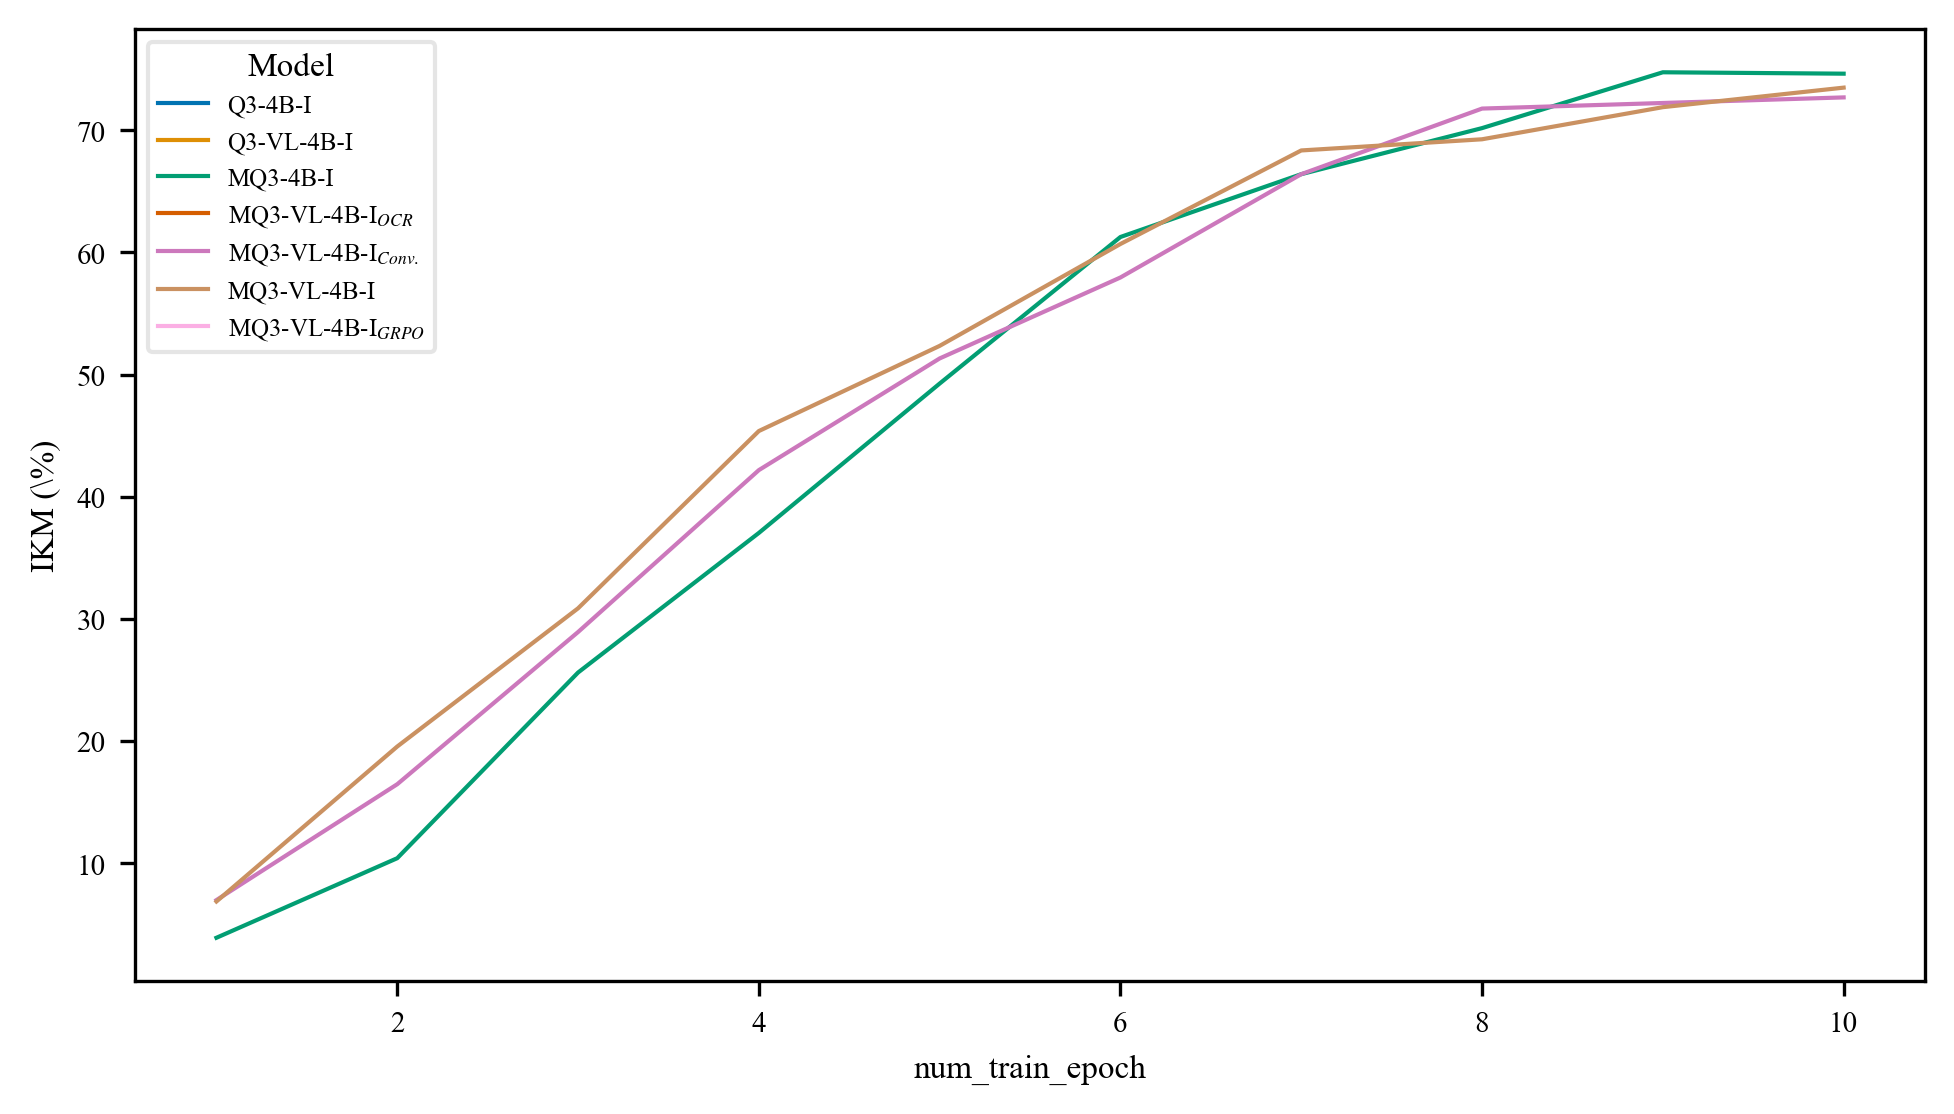

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

clean_df = tmp_df.copy()
clean_df = clean_df[clean_df.Model.isin(["MQ3-4B-I", "MQ3-VL-4B-I$_{Conv.}$", "MQ3-VL-4B-I"])]

w = 6.4 # inchi
ratio = 16/9
h = w / ratio
figsize = (w, h)
fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(data=clean_df, x="num_train_epoch", y="IKM (\\%)", ax=ax, hue="Model")

## WANDB: SFT

In [38]:
import os
os.environ["WANDB_API_KEY"] = "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"
import wandb

api = wandb.Api()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


In [39]:
run_mq3_vl_ocr = api.run("kdeng03-proj/mol-llm/8zyq1qb3")
run_mq3_vl_conv = api.run("kdeng03-proj/mol-llm/hdwturde")
run_mq3_vl_ocr_conv_p1 = api.run("kdeng03-proj/mol-llm/btul78eh")
run_mq3_vl_ocr_conv_p2 = api.run("kdeng03-proj/mol-llm/yvbghwcq")
run_mq3_conv = api.run("kdeng03-proj/mol-llm/75nvkrvc")

In [40]:
history_mq3_vl_ocr = pd.DataFrame(run_mq3_vl_ocr.scan_history())
history_mq3_vl_conv = pd.DataFrame(run_mq3_vl_conv.scan_history())
history_mq3_vl_ocr_conv_p1 = pd.DataFrame(run_mq3_vl_ocr_conv_p1.scan_history())
history_mq3_vl_ocr_conv_p2 = pd.DataFrame(run_mq3_vl_ocr_conv_p2.scan_history())
history_mq3_vl_ocr_conv = pd.concat([history_mq3_vl_ocr_conv_p1, history_mq3_vl_ocr_conv_p2], ignore_index=True)
history_mq3_conv = pd.DataFrame(run_mq3_conv.scan_history())

In [41]:
history_mq3_vl_ocr_conv = history_mq3_vl_ocr_conv.drop(index=255)
history_mq3_vl_ocr_conv = history_mq3_vl_ocr_conv.reset_index(drop=True)
history_mq3_vl_ocr_conv["_step"] = history_mq3_vl_ocr_conv.index

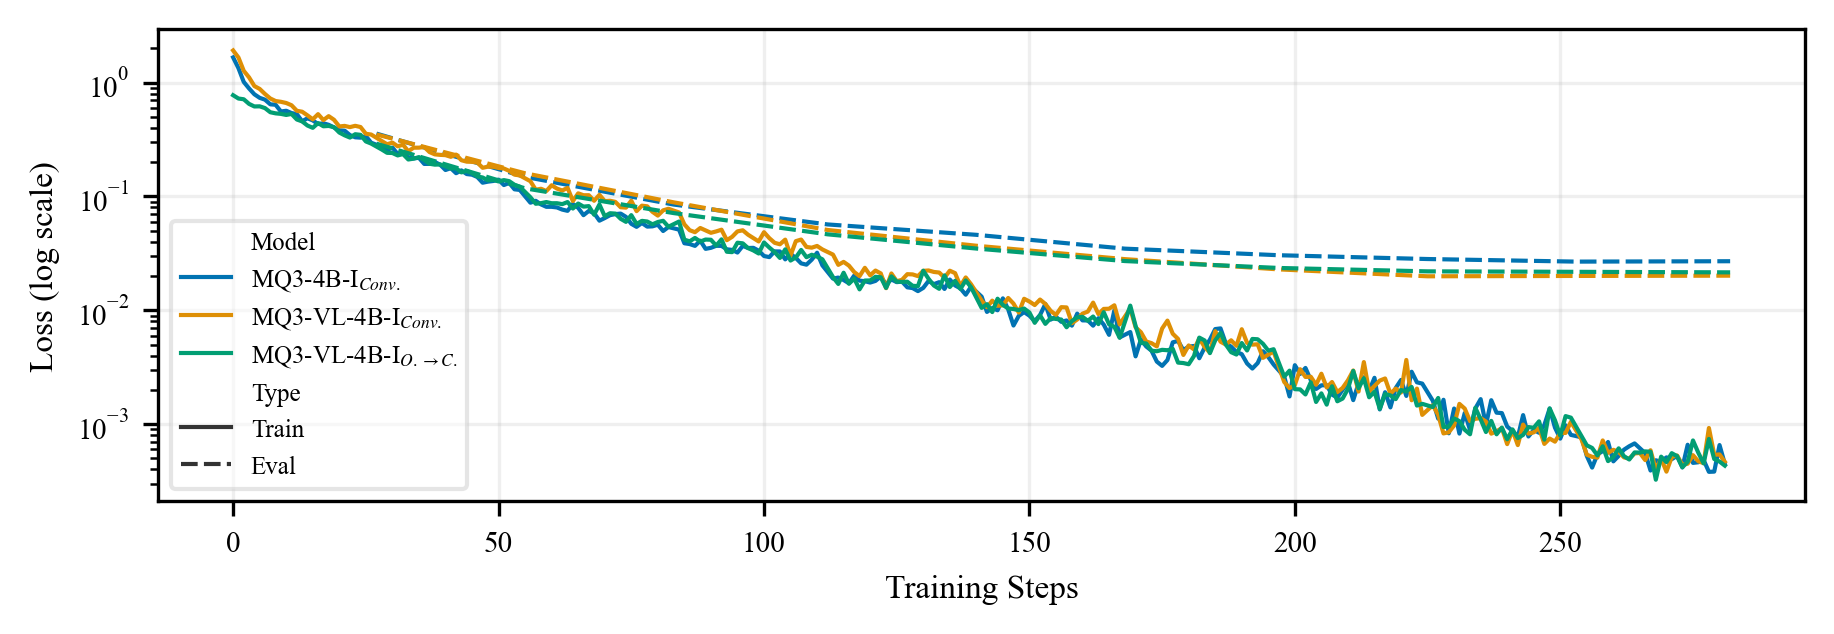

In [35]:
# 绘制 3 个模型的训练曲线对比 (Train 和 Eval Loss 在同一张图)
import matplotlib.pyplot as plt
import seaborn as sns

# 准备数据: 合并 3 个模型的 history
df_mq3_conv = history_mq3_conv[["_step", "train/loss", "eval/loss"]].copy()
df_mq3_conv["Model"] = "MQ3-4B-I$_{Conv.}$"

df_mq3_vl_conv = history_mq3_vl_conv[["_step", "train/loss", "eval/loss"]].copy()
df_mq3_vl_conv["Model"] = "MQ3-VL-4B-I$_{Conv.}$"

df_mq3_vl_ocr_conv = history_mq3_vl_ocr_conv[["_step", "train/loss", "eval/loss"]].copy()
df_mq3_vl_ocr_conv["Model"] = "MQ3-VL-4B-I$_{O. \\to C.}$"

# 合并所有数据
combined = pd.concat([df_mq3_conv, df_mq3_vl_conv, df_mq3_vl_ocr_conv], ignore_index=True)

# 转换为长格式 (适合 seaborn 绘图)
train_data = combined[["_step", "train/loss", "Model"]].rename(columns={"train/loss": "loss"})
train_data["Type"] = "Train"

eval_data = combined[["_step", "eval/loss", "Model"]].rename(columns={"eval/loss": "loss"})
eval_data["Type"] = "Eval"

plot_data = pd.concat([train_data, eval_data], ignore_index=True)

# 创建图表
w = 6.4
ratio = 16/9
h = w / ratio
figsize = (w, h)
fig, ax = plt.subplots()

# 使用 seaborn 绘制,自动按 model 和 type 分颜色/线型
sns.lineplot(
    data=plot_data,
    x="_step",
    y="loss",
    hue="Model",
    style="Type",
    linewidth=1,
    markers=False,
    dashes=True,
    ax=ax,
)

# 设置标签和标题
ax.set_xlabel("Training Steps")
ax.set_ylabel("Loss (log scale)")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.2)

# plt.tight_layout()
plt.show()

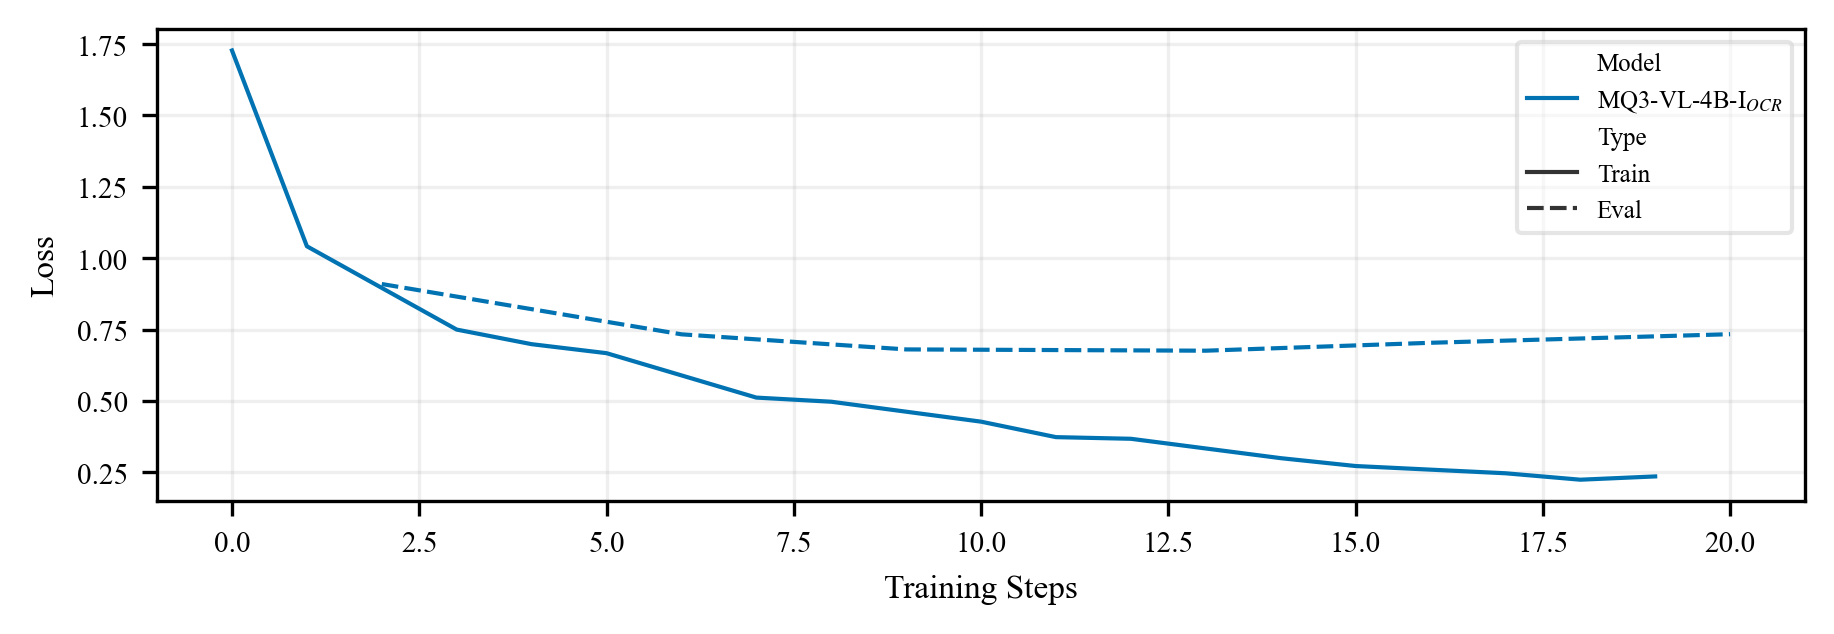

In [36]:
# 绘制 OCR 模型的训练曲线 (Train 和 Eval Loss)
# 准备数据
df_ocr = history_mq3_vl_ocr[["_step", "train/loss", "eval/loss"]].copy()
df_ocr["Model"] = "MQ3-VL-4B-I$_{OCR}$"

# 转换为长格式
train_data = df_ocr[["_step", "train/loss", "Model"]].rename(columns={"train/loss": "loss"})
train_data["Type"] = "Train"

eval_data = df_ocr[["_step", "eval/loss", "Model"]].rename(columns={"eval/loss": "loss"})
eval_data["Type"] = "Eval"

plot_data = pd.concat([train_data, eval_data], ignore_index=True)

# 创建图表
w = 5.9
ratio = 2/1
h = w / ratio
figsize = (w, h)
fig, ax = plt.subplots()

# 使用 seaborn 绘制
sns.lineplot(
    data=plot_data,
    x="_step",
    y="loss",
    hue="Model",
    style="Type",
    linewidth=1,
    markers=False,
    dashes=True,
    ax=ax,
)

# 设置标签和标题
ax.set_xlabel("Training Steps")
ax.set_ylabel("Loss")
# ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.2)

# plt.tight_layout()
plt.show()

In [6]:
import matplotlib.pyplot as plt

def set_rc_params():
    w = 6
    ratio = 3/1
    h = w / ratio
    figsize = (w, h)

    general_font_size = 8
    general_tick_size = 7
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": general_font_size,
        "mathtext.fontset": "stix",

        "axes.titlesize": general_font_size,
        "axes.labelsize": general_font_size,

        "xtick.labelsize": general_tick_size,
        "ytick.labelsize": general_tick_size,

        "legend.fontsize": 6,
        "legend.frameon": True,
        "legend.framealpha": 0.5,

        "figure.titlesize": 10,
        "figure.figsize": figsize,
        "figure.constrained_layout.use": True,
        "figure.dpi": 300,

        "lines.linewidth": 1.,

        "savefig.dpi": 300,
    })

set_rc_params()

import seaborn as sns

sns.set_palette("colorblind")
# sns.set_palette(PALETTE)

MODEL_PALETTE = {
    "Q3-4B-I": "#c5c5e0",
    "MQ3-4B-I": "#3c58a7",
    "MQ3-4B-I$_{Conv.}$": "#3c58a7",

    "Q3-VL-4B-I": "#fbcdcd",    
    "MQ3-VL-4B-I$_{OCR}$": "#F8AB61",
    "MQ3-VL-4B-I$_{Conv.}$": "#65C3A5",
    "MQ3-VL-4B-I$_{O. \\to C.}$": "#ed3525",
    "MQ3-VL-4B-I": "#ed3525",
}


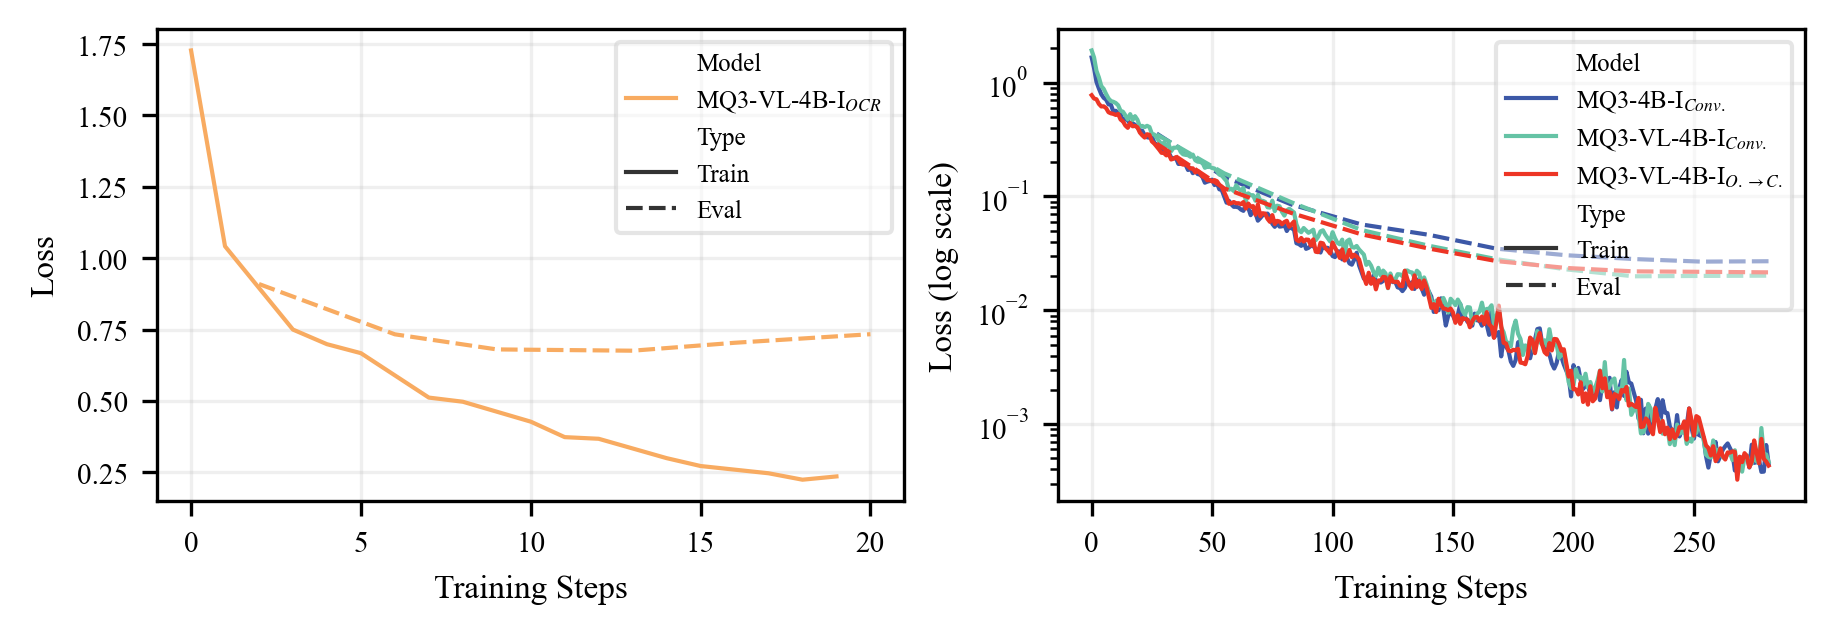

In [43]:
# 合并两个图到 1 行 2 列
fig, axes = plt.subplots(1, 2)

# --- 左图: 3 个 Conversion 模型 ---
df_mq3_conv = history_mq3_conv[["_step", "train/loss", "eval/loss"]].copy()
df_mq3_conv["Model"] = "MQ3-4B-I$_{Conv.}$"

df_mq3_vl_conv = history_mq3_vl_conv[["_step", "train/loss", "eval/loss"]].copy()
df_mq3_vl_conv["Model"] = "MQ3-VL-4B-I$_{Conv.}$"

df_mq3_vl_ocr_conv = history_mq3_vl_ocr_conv[["_step", "train/loss", "eval/loss"]].copy()
df_mq3_vl_ocr_conv["Model"] = "MQ3-VL-4B-I$_{O. \\to C.}$"

combined_conv = pd.concat([df_mq3_conv, df_mq3_vl_conv, df_mq3_vl_ocr_conv], ignore_index=True)
train_data_conv = combined_conv[["_step", "train/loss", "Model"]].rename(columns={"train/loss": "loss"})
train_data_conv["Type"] = "Train"
eval_data_conv = combined_conv[["_step", "eval/loss", "Model"]].rename(columns={"eval/loss": "loss"})
eval_data_conv["Type"] = "Eval"
plot_data_conv = pd.concat([train_data_conv, eval_data_conv], ignore_index=True)

sns.lineplot(
    data=plot_data_conv, x="_step", y="loss", hue="Model", style="Type",
    markers=False, dashes=True, ax=axes[1], palette=MODEL_PALETTE,
)
axes[1].set_xlabel("Training Steps")
axes[1].set_ylabel("Loss (log scale)")
axes[1].set_yscale("log")
# axes[1].set_title("Conversion Models")
axes[1].legend()
axes[1].grid(True, alpha=0.2)

# --- 右图: OCR 模型 ---
df_ocr = history_mq3_vl_ocr[["_step", "train/loss", "eval/loss"]].copy()
df_ocr["Model"] = "MQ3-VL-4B-I$_{OCR}$"

train_data_ocr = df_ocr[["_step", "train/loss", "Model"]].rename(columns={"train/loss": "loss"})
train_data_ocr["Type"] = "Train"
eval_data_ocr = df_ocr[["_step", "eval/loss", "Model"]].rename(columns={"eval/loss": "loss"})
eval_data_ocr["Type"] = "Eval"
plot_data_ocr = pd.concat([train_data_ocr, eval_data_ocr], ignore_index=True)

sns.lineplot(
    data=plot_data_ocr, x="_step", y="loss", hue="Model", style="Type",
    markers=False, dashes=True, ax=axes[0], palette=MODEL_PALETTE,
)
axes[0].set_xlabel("Training Steps")
axes[0].set_ylabel("Loss")
# axes[0].set_yscale("log")
# axes[0].set_title("OCR Model")
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# plt.tight_layout()
plt.savefig("results/paper_writing/figs/sft_loss.pdf")
plt.show()

## Rollout

In [22]:
rollout_dir
tmp_dir = rollout_dir / "mol-rep-conversion" / "v1.1" / "test" / "qwen3_vl_4b_i_sft_lora_ocr_conversion_pass_at_16.csv"

In [33]:
def prepare_rollout_results(file):
    raw_df = pd.read_csv(file)

    col_names = {
        "k": "K",
        "pass_at_k_ratio": "Pass@K (\\%)",
        "incremental_pass_ratio": "Incr. Pass@K (\\%)",
        "valid_rate_at_k": "Valid@K (\\%)",
        "all_correct_at_k": "All Correct@K (\\%)",
        "all_wrong_at_k": "All Wrong@K (\\%)",
    }

    clean_df = raw_df.copy()
    clean_df = clean_df.rename(columns=col_names)
    clean_df = clean_df[["K", "Pass@K (\\%)", "Incr. Pass@K (\\%)", "Valid@K (\\%)", "All Correct@K (\\%)", "All Wrong@K (\\%)"]]
    clean_df[[ "Pass@K (\\%)" ]] = clean_df[["Pass@K (\\%)"]] * 100
    clean_df[[ "Incr. Pass@K (\\%)" ]] = clean_df[["Incr. Pass@K (\\%)"]] * 100
    clean_df[[ "Valid@K (\\%)" ]] = clean_df[["Valid@K (\\%)"]] * 100
    clean_df[[ "All Correct@K (\\%)" ]] = clean_df[["All Correct@K (\\%)"]] * 100
    clean_df[[ "All Wrong@K (\\%)" ]] = clean_df[["All Wrong@K (\\%)"]] * 100
    clean_df = clean_df.round(2)

    return clean_df

In [34]:
tmp_df = prepare_rollout_results(tmp_dir)
tmp_df

,K,Pass@K (\%),Incr. Pass@K (\%),Valid@K (\%),All Correct@K (\%),All Wrong@K (\%)
0,1,67.89,67.89,87.09,67.89,32.11
1,2,76.11,8.23,87.89,60.46,23.89
2,4,80.11,4.00,87.89,54.06,19.89
3,8,84.34,4.23,88.21,46.17,15.66
4,16,86.74,2.40,88.29,39.09,13.26


In [35]:
print(tmp_df.to_latex(
    float_format="%.2f",
    index=False,
))

\begin{tabular}{rrrrrr}
\toprule
K & Pass@K (\%) & Incr. Pass@K (\%) & Valid@K (\%) & All Correct@K (\%) & All Wrong@K (\%) \\
\midrule
1 & 67.89 & 67.89 & 87.09 & 67.89 & 32.11 \\
2 & 76.11 & 8.23 & 87.89 & 60.46 & 23.89 \\
4 & 80.11 & 4.00 & 87.89 & 54.06 & 19.89 \\
8 & 84.34 & 4.23 & 88.21 & 46.17 & 15.66 \\
16 & 86.74 & 2.40 & 88.29 & 39.09 & 13.26 \\
\bottomrule
\end{tabular}



## GRPO

In [45]:
run_mq3_vl_grpo_p1 = api.run("kdeng03-proj/mol-llm/pjm01zhp")
run_mq3_vl_grpo_p2 = api.run("kdeng03-proj/mol-llm/kk9zwsqw")

In [46]:
history_mq3_vl_grpo_p1 = pd.DataFrame(run_mq3_vl_grpo_p1.scan_history())
# history_mq3_vl_grpo_p2 = pd.DataFrame(run_mq3_vl_grpo_p2.scan_history())
# history_mq3_vl_grpo = pd.concat([history_mq3_vl_grpo_p1, history_mq3_vl_grpo_p2], ignore_index=True)

In [47]:
history_mq3_vl_grpo = history_mq3_vl_grpo_p1[history_mq3_vl_grpo_p1["train/global_step"] <= 126]

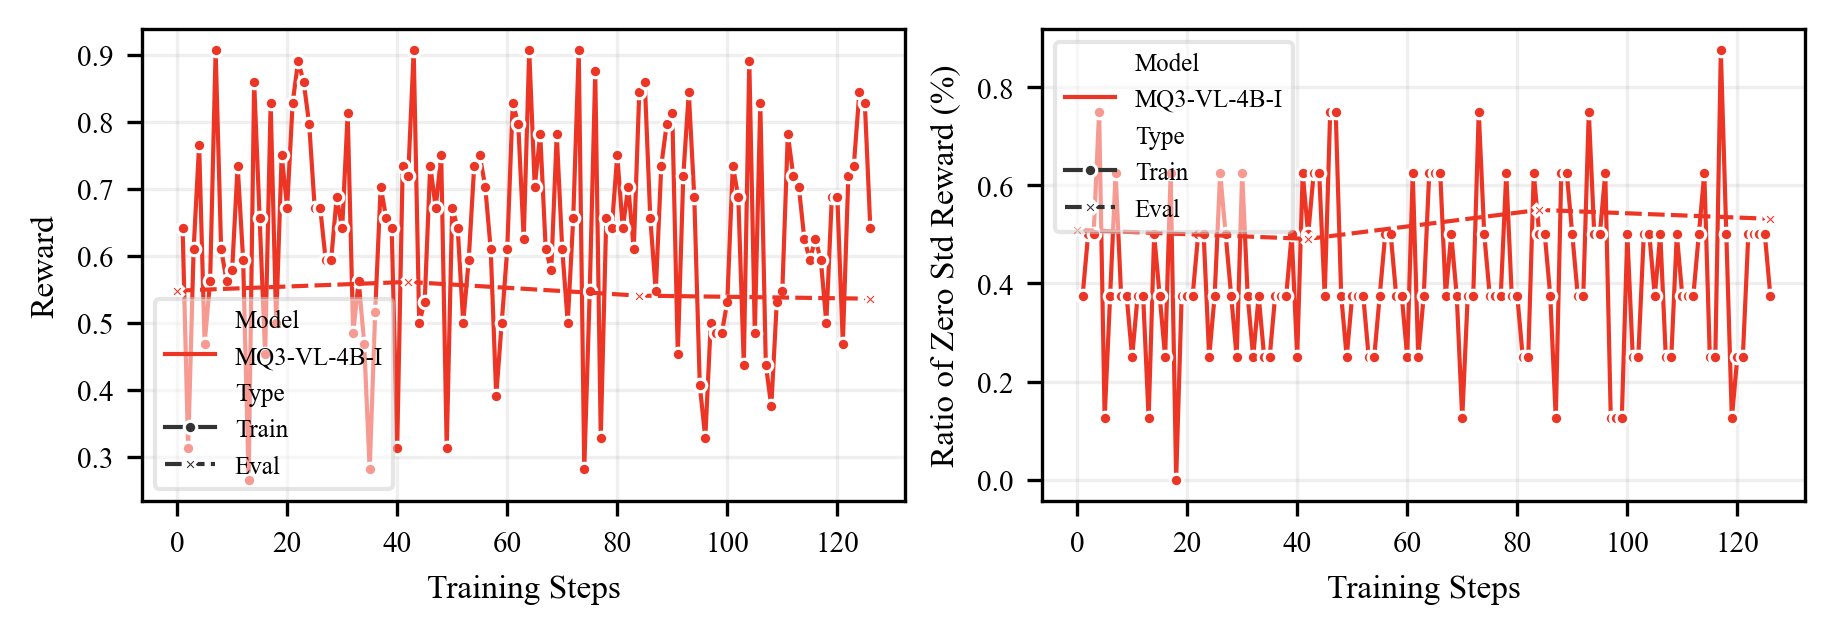

In [49]:
# 绘制 GRPO 的 Reward 曲线 (1x2 figure)
# 左图: train/reward vs eval/reward
# 右图: train/frac_reward_zero_std vs eval/reward

# 准备数据
train_reward = history_mq3_vl_grpo[["train/global_step", "train/reward"]].copy()
eval_reward = history_mq3_vl_grpo[["train/global_step", "eval/reward"]].copy()
train_frac_reward = history_mq3_vl_grpo[["train/global_step", "train/frac_reward_zero_std"]].copy()
eval_frac_reward = history_mq3_vl_grpo[["train/global_step", "eval/frac_reward_zero_std"]].copy()


# 左图数据
left_train = train_reward.copy()
left_train["Model"] = "MQ3-VL-4B-I"
left_train["Type"] = "Train"
left_train = left_train.rename(columns={"train/reward": "reward"})

left_eval = eval_reward.copy()
left_eval["Model"] = "MQ3-VL-4B-I"
left_eval["Type"] = "Eval"
left_eval = left_eval.rename(columns={"eval/reward": "reward"})

left_data = pd.concat([left_train, left_eval], ignore_index=True)

# 右图数据
right_train = train_frac_reward.copy()
right_train["Model"] = "MQ3-VL-4B-I"
right_train["Type"] = "Train"
right_train = right_train.rename(columns={"train/frac_reward_zero_std": "ratio"})

right_eval = eval_frac_reward.copy()
right_eval["Model"] = "MQ3-VL-4B-I"
right_eval["Type"] = "Eval"
right_eval = right_eval.rename(columns={"eval/frac_reward_zero_std": "ratio"})

right_data = pd.concat([right_train, right_eval], ignore_index=True)

# 创建 1x2 figure
fig, axes = plt.subplots(1, 2)

# 左图: train/reward vs eval/reward
sns.lineplot(
    data=left_data,
    x="train/global_step",
    y="reward",
    hue="Model",
    style="Type",
    markers=True,
    markersize=3,
    dashes=True,
    ax=axes[0],
    palette=MODEL_PALETTE,
)
axes[0].set_xlabel("Training Steps")
axes[0].set_ylabel("Reward")
# axes[0].set_title("train/reward vs eval/reward")
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# 右图: train/frac_reward_zero_std vs eval/reward
sns.lineplot(
    data=right_data,
    x="train/global_step",
    y="ratio",
    hue="Model",
    style="Type",
    markers=True,
    markersize=3,
    dashes=True,
    ax=axes[1],
    palette=MODEL_PALETTE,
)
axes[1].set_xlabel("Training Steps")
axes[1].set_ylabel("Ratio of Zero Std Reward (%)")
# axes[1].set_title("train/frac_reward_zero_std vs eval/frac_reward_zero_std")
axes[1].legend()
axes[1].grid(True, alpha=0.2)

# plt.tight_layout()
plt.savefig("results/paper_writing/figs/grpo_on_hard.pdf")
plt.show()

In [50]:
run_mq3_vl_sft_stage2 = api.run("kdeng03-proj/mol-llm/tyq4ec2f")

In [51]:
history_mq3_vl_sft_stage2 = pd.DataFrame(run_mq3_vl_sft_stage2.scan_history())

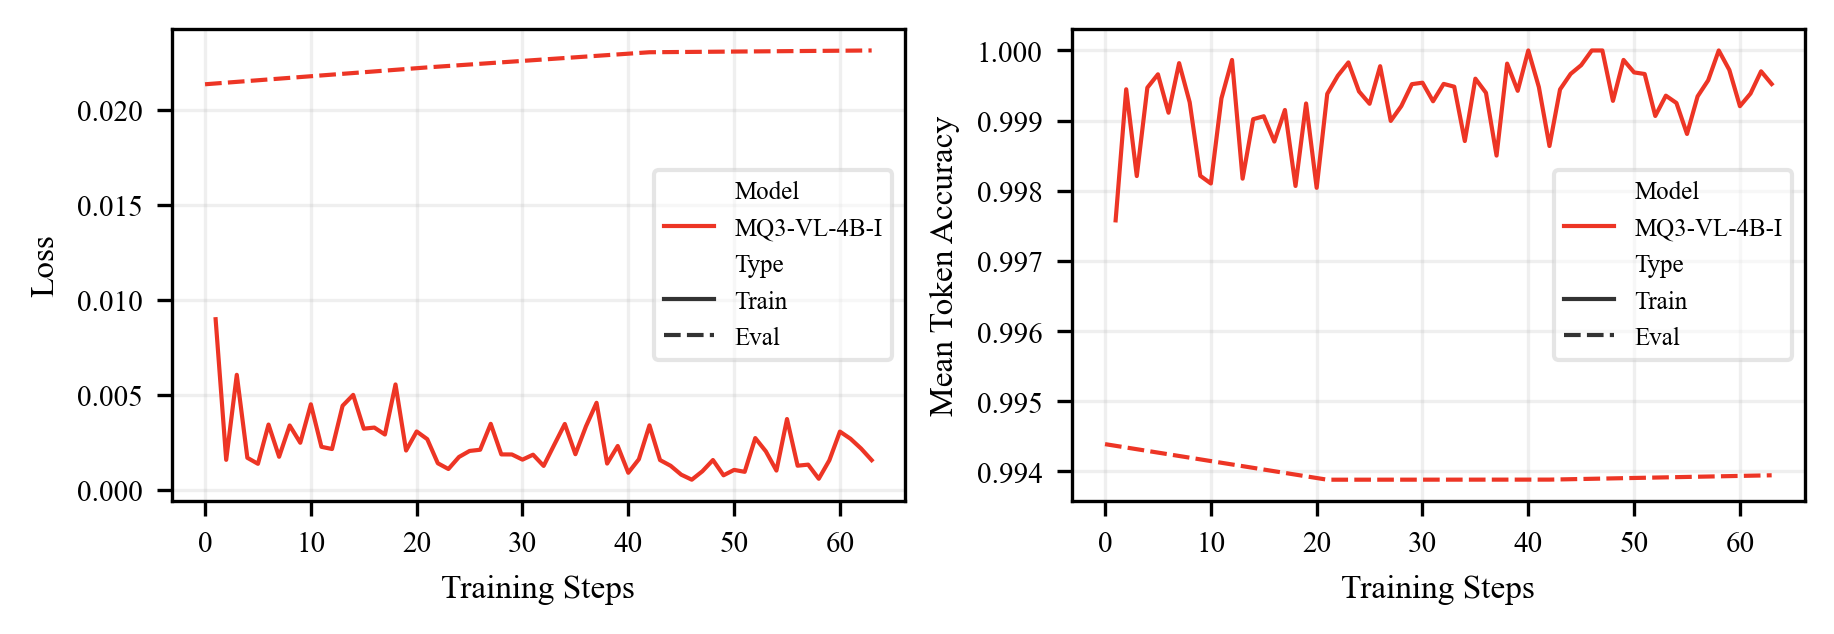

In [52]:
# 绘制 SFT Stage2 的训练曲线 (1x2 figure)
# 左图: train/loss vs eval/loss
# 右图: train/mean_token_accuracy vs eval/mean_token_accuracy

# 准备数据 - Loss
train_loss = history_mq3_vl_sft_stage2[["train/global_step", "train/loss"]].copy()
eval_loss = history_mq3_vl_sft_stage2[["train/global_step", "eval/loss"]].copy()

train_loss["Model"] = "MQ3-VL-4B-I"
train_loss["Type"] = "Train"
train_loss = train_loss.rename(columns={"train/loss": "value"})

eval_loss["Model"] = "MQ3-VL-4B-I"
eval_loss["Type"] = "Eval"
eval_loss = eval_loss.rename(columns={"eval/loss": "value"})

loss_data = pd.concat([train_loss, eval_loss], ignore_index=True)

# 准备数据 - Mean Token Accuracy
train_acc = history_mq3_vl_sft_stage2[["train/global_step", "train/mean_token_accuracy"]].copy()
eval_acc = history_mq3_vl_sft_stage2[["train/global_step", "eval/mean_token_accuracy"]].copy()

train_acc["Model"] = "MQ3-VL-4B-I"
train_acc["Type"] = "Train"
train_acc = train_acc.rename(columns={"train/mean_token_accuracy": "value"})

eval_acc["Model"] = "MQ3-VL-4B-I"
eval_acc["Type"] = "Eval"
eval_acc = eval_acc.rename(columns={"eval/mean_token_accuracy": "value"})

acc_data = pd.concat([train_acc, eval_acc], ignore_index=True)

# 创建 1x2 figure
fig, axes = plt.subplots(1, 2)

# 左图: Loss
sns.lineplot(
    data=loss_data,
    x="train/global_step",
    y="value",
    hue="Model",
    style="Type",
    linewidth=1,
    markers=False,
    markersize=3,
    dashes=True,
    ax=axes[0],
    palette=MODEL_PALETTE,
)
axes[0].set_xlabel("Training Steps")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# 右图: Mean Token Accuracy
sns.lineplot(
    data=acc_data,
    x="train/global_step",
    y="value",
    hue="Model",
    style="Type",
    linewidth=1,
    markers=False,
    markersize=3,
    dashes=True,
    ax=axes[1],
    palette=MODEL_PALETTE,
)
axes[1].set_xlabel("Training Steps")
axes[1].set_ylabel("Mean Token Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.savefig("results/paper_writing/figs/sft_on_hard.pdf")
plt.show()

## MolRepBench

In [2]:
from pathlib import Path
import pandas as pd

tmp_dir = Path("../molrepbench/results_small")
cross_dir = tmp_dir / "cross"
metrics_dir = tmp_dir / "metrics"

In [3]:
def preprocess(dir):
    dir = Path(dir)
    cross_dir = dir / "cross"
    metrics_dir = dir / "metrics"
    cross_df = pd.read_csv(cross_dir / "comprehension_vs_generation.csv")
    b9_df = pd.read_csv(metrics_dir / "benchmark_9_metrics.csv")
    b10_df = pd.read_csv(metrics_dir / "benchmark_10_metrics.csv")

    cross_df = cross_df.groupby(["model"])[["b1_score", "b2_score", "b3_score", "b4_score", "b5_score", "b6_score", "mean_comprehension", "mean_generation"]].mean().reset_index()
    b9_df = b9_df[b9_df["pair_type"] == "overall"].groupby(["model"])[["accuracy", "precision", "recall", "f1"]].mean().reset_index()
    b10_df = b10_df[b10_df["pair_type"] == "overall"].groupby(["model"])[["accuracy", "precision", "recall", "f1"]].mean().reset_index()

    b9_df = b9_df.rename(columns={"f1": "b9_score"})
    b10_df = b10_df.rename(columns={"f1": "b10_score"})

    final_df = cross_df.merge(b9_df[["model", "b9_score"]], on="model", how="left").merge(b10_df[["model", "b10_score"]], on="model", how="left")

    col_names = {
        "model": "Model",
        "b1_score": "B1 (C)",
        "b2_score": "B2 (C)",
        "b3_score": "B3 (C)",
        "b4_score": "B4 (C)",
        "b5_score": "B5 (D)",
        "b6_score": "B6 (G)",
        "b9_score": "B7 (D)",
        "b10_score": "B8 (D)",
        "mean_comprehension": "Comprehension",
        "mean_generation": "Generation"
    }
    final_df = final_df.rename(columns=col_names)

    final_df["Comprehension"] = final_df.apply(lambda row: (row["B1 (C)"] + row["B2 (C)"] + row["B3 (C)"] + row["B4 (C)"]) / 4, axis=1)
    final_df["Discrimination"] = final_df.apply(lambda row: (row["B5 (D)"] + row["B7 (D)"] + row["B8 (D)"]) / 3, axis=1)
    final_df["Generation"] = final_df.apply(lambda row: row["B6 (G)"], axis=1)

    def _rename_model_name(df):
        tmp_map = {
            "qwen3-4b-instruct-2507": "Q3-4B-I",
            "qwen3-vl-4b-instruct": "Q3-VL-4B-I",
            "molqwen3-4b-instruct-sft": "MQ3-4B-I",
            "molqwen3-vl-4b-instruct-sft": "MQ3-VL-4B-I",
        }
        df["Model"] = df["Model"].replace(tmp_map)
        model_name_order = [
            "Q3-4B-I",
            "Q3-VL-4B-I",
            "MQ3-4B-I",
            "MQ3-VL-4B-I",
        ]
        df["Model"] = pd.Categorical(df["Model"], categories=model_name_order, ordered=True)
        return df

    final_df = _rename_model_name(final_df)

    return final_df


tmp_df = preprocess(tmp_dir)

In [4]:
tmp_df

,Model,B1 (C),B2 (C),B3 (C),B4 (C),B5 (D),B6 (G),Comprehension,Generation,B7 (D),B8 (D),Discrimination
0,MQ3-4B-I,0.252222,0.269596,0.620268,0.575499,0.068281,0.313248,0.429396,0.313248,0.802304,0.523372,0.464652
1,MQ3-VL-4B-I,0.227778,0.280452,0.574110,0.598291,0.011975,0.313404,0.420158,0.313404,0.676924,0.775642,0.488180
2,Q3-4B-I,0.251667,0.247047,0.689895,0.568376,0.001602,0.240649,0.439246,0.240649,0.357240,0.763244,0.374029
3,Q3-VL-4B-I,0.297778,0.285862,0.405191,0.555556,0.003120,0.258793,0.386097,0.258793,0.268804,0.519876,0.263933


In [21]:
# plot_delta_df

,Modality,Benchmark,Delta (%)
0,LLM,Comprehension,-2.242476
1,MLLM,Comprehension,8.821906
2,LLM,Discrimination,24.228858
3,MLLM,Discrimination,84.963400
4,LLM,Generation,30.168350
5,MLLM,Generation,21.102111


In [9]:
# plot_delta_df["Delta (%)"].mean() # 27.84%

np.float64(27.840358205478584)

In [ ]:
# # 计算 Delta 百分比: (Trained - Base) / Base * 100
# base_llm = tmp_df[tmp_df["Model"] == "Q3-4B-I"][bench_cols].reset_index(drop=True)
# trained_llm = tmp_df[tmp_df["Model"] == "MQ3-4B-I"][bench_cols].reset_index(drop=True)
# delta_llm = ((trained_llm - base_llm) / base_llm * 100)
# delta_llm["Modality"] = "LLM"

# base_vlm = tmp_df[tmp_df["Model"] == "Q3-VL-4B-I"][bench_cols].reset_index(drop=True)
# trained_vlm = tmp_df[tmp_df["Model"] == "MQ3-VL-4B-I"][bench_cols].reset_index(drop=True)
# delta_vlm = ((trained_vlm - base_vlm) / base_vlm * 100)
# delta_vlm["Modality"] = "MLLM"

# delta_df = pd.concat([delta_llm, delta_vlm], ignore_index=True)

In [18]:
# delta_df
# plot_delta_df = delta_df.melt(
#     id_vars=["Modality"],
#     value_vars=bench_cols,
#     var_name="Benchmark",
#     value_name="Delta (%)"
# )
# plot_delta_df

,Modality,Benchmark,Delta (%)
0,LLM,B1 (C),0.220751
1,MLLM,B1 (C),-23.507463
2,LLM,B2 (C),9.127385
3,MLLM,B2 (C),-1.892523
4,LLM,B3 (C),-10.092400
5,MLLM,B3 (C),41.688815
6,LLM,B4 (C),1.253133
7,MLLM,B4 (C),7.692308
8,LLM,B5 (D),4161.117811
9,MLLM,B5 (D),283.767652


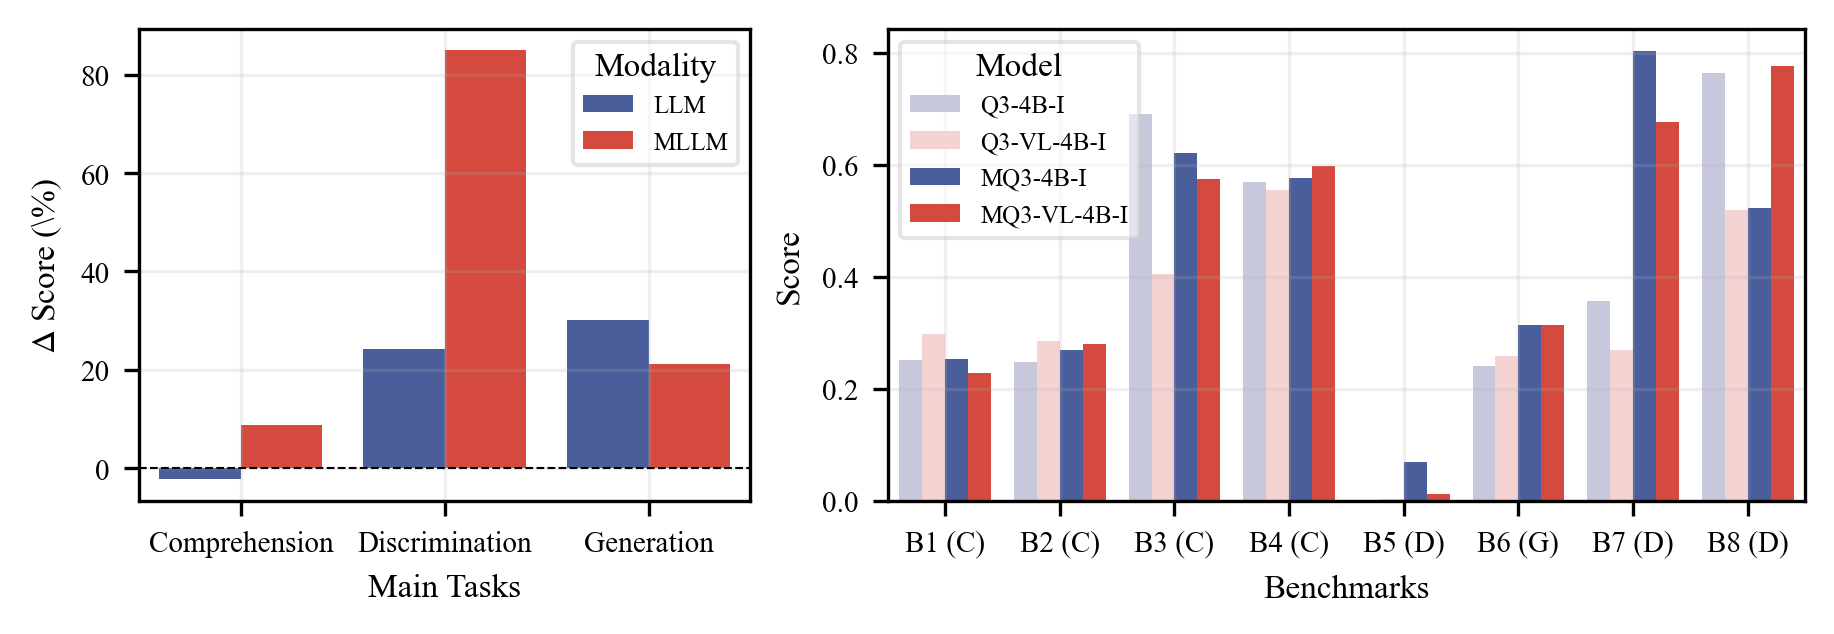

In [19]:
# 选择要绘制的 benchmark 列
agg_cols = ["Comprehension", "Discrimination", "Generation"]
bench_cols = ["B1 (C)", "B2 (C)", "B3 (C)", "B4 (C)", "B5 (D)", "B6 (G)", "B7 (D)", "B8 (D)"]

# 计算 Delta 百分比: (Trained - Base) / Base * 100
base_llm = tmp_df[tmp_df["Model"] == "Q3-4B-I"][agg_cols].reset_index(drop=True)
trained_llm = tmp_df[tmp_df["Model"] == "MQ3-4B-I"][agg_cols].reset_index(drop=True)
delta_llm = ((trained_llm - base_llm) / base_llm * 100)
delta_llm["Modality"] = "LLM"

base_vlm = tmp_df[tmp_df["Model"] == "Q3-VL-4B-I"][agg_cols].reset_index(drop=True)
trained_vlm = tmp_df[tmp_df["Model"] == "MQ3-VL-4B-I"][agg_cols].reset_index(drop=True)
delta_vlm = ((trained_vlm - base_vlm) / base_vlm * 100)
delta_vlm["Modality"] = "MLLM"

delta_df = pd.concat([delta_llm, delta_vlm], ignore_index=True)

# 宽格式 -> 长格式 (Delta)
plot_delta_df = delta_df.melt(
    id_vars=["Modality"],
    value_vars=agg_cols,
    var_name="Benchmark",
    value_name="Delta (%)"
)

# 右图: 8 个具体 benchmark
plot_bench_df = tmp_df.melt(
    id_vars=["Model"],
    value_vars=bench_cols,
    var_name="Benchmark",
    value_name="Score"
)

# 创建 1x2 figure
fig, axes = plt.subplots(1, 2, gridspec_kw={"width_ratios": [4, 6]})

MODEL_PALETTE = {
    "Q3-4B-I": "#c5c5e0",
    "MQ3-4B-I": "#3c58a7",
    "MQ3-4B-I$_{Conv.}$": "#3c58a7",

    "Q3-VL-4B-I": "#fbcdcd",    
    "MQ3-VL-4B-I$_{OCR}$": "#F8AB61",
    "MQ3-VL-4B-I$_{Conv.}$": "#65C3A5",
    "MQ3-VL-4B-I$_{O. \\to C.}$": "#ed3525",
    "MQ3-VL-4B-I": "#ed3525",
}

# 左图: Delta 百分比任务
sns.barplot(
    data=plot_delta_df,
    x="Benchmark",
    y="Delta (%)",
    hue="Modality",
    ax=axes[0],
    palette=["#3c58a7", "#ed3525"],
)
axes[0].set_xlabel("Main Tasks")
axes[0].set_ylabel("$\\Delta$ Score (\\%)")
axes[0].axhline(y=0, color="black", linewidth=0.5, linestyle="--")
axes[0].grid(True, alpha=0.2)

# 右图: 8 个具体 benchmark
sns.barplot(
    data=plot_bench_df,
    x="Benchmark",
    y="Score",
    hue="Model",
    ax=axes[1],
    palette=MODEL_PALETTE,
)
axes[1].set_xlabel("Benchmarks")
axes[1].set_ylabel("Score")
axes[1].grid(True, alpha=0.2)

# plt.tight_layout()
plt.savefig("results/paper_writing/figs/molrepbench.pdf")
plt.show()